# Stage 8: Covariance Research Engine
This notebook compares sample covariance, Ledoit-Wolf shrinkage, EWMA covariance, and EWMA plus Ledoit-Wolf shrinkage using a deterministic return sample.

In [1]:
import os
import sys
from pathlib import Path

notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.covariance import CovarianceFactory, extract_covariance_metadata

plt.style.use('seaborn-v0_8')
sns.set_theme(style='white')


## 1. Load Returns Data
To keep the notebook reproducible and offline-friendly, we generate a deterministic multi-asset return sample with shared factor structure and idiosyncratic noise.

In [3]:
np.random.seed(42)

dates = pd.date_range(start='2021-01-01', periods=756, freq='B')
factor = np.random.normal(0.0, 0.008, size=(len(dates), 1))
idiosyncratic = np.random.normal(0.0, 0.012, size=(len(dates), 5))
loadings = np.array([[1.0, 0.7, 0.4, -0.2, 0.6]])

returns = factor @ loadings + idiosyncratic
returns_df = pd.DataFrame(
    returns,
    index=dates,
    columns=['Asset A', 'Asset B', 'Asset C', 'Asset D', 'Asset E'],
)

print('Returns shape:', returns_df.shape)
print('Date range:', returns_df.index[0], 'to', returns_df.index[-1])
returns_df.head()


Returns shape: (756, 5)
Date range: 2021-01-01 00:00:00 to 2023-11-24 00:00:00


,Asset A,Asset B,Asset C,Asset D,Asset E
2021-01-01,0.009894,0.005000,-0.008711,0.007609,-0.004523
2021-01-04,0.000358,0.029947,-0.001595,0.014013,-0.009102
2021-01-05,0.004762,0.024877,-0.005451,0.020713,0.011602
2021-01-06,0.005435,0.016118,0.016544,0.005025,-0.011532
2021-01-07,-0.010599,-0.004281,-0.001642,0.007823,0.001008


## 2-5. Compute Covariance Estimators
We compute all supported covariance estimators through the new factory interface and inspect their attached metadata.

In [4]:
sample_cov = CovarianceFactory.compute(returns_df, method='sample')
ledoit_cov = CovarianceFactory.compute(returns_df, method='ledoit_wolf')
ewma_cov = CovarianceFactory.compute(returns_df, method='ewma', span=126)
ewma_ledoit_cov = CovarianceFactory.compute(
    returns_df,
    method='ewma_ledoit_wolf',
    span=126,
)

covariances = {
    'Sample': sample_cov,
    'Ledoit-Wolf': ledoit_cov,
    'EWMA': ewma_cov,
    'EWMA + Ledoit-Wolf': ewma_ledoit_cov,
}

metadata_summary = pd.DataFrame(
    [extract_covariance_metadata(matrix) for matrix in covariances.values()],
    index=covariances.keys(),
)
metadata_summary


,method,shrinkage,span
Sample,sample,NaN,NaN
Ledoit-Wolf,ledoit_wolf,0.083578,NaN
EWMA,ewma,NaN,126.0
EWMA + Ledoit-Wolf,ewma_ledoit_wolf,0.336807,126.0


## 6. Heatmap Comparison
The first figure compares the covariance levels directly. The second highlights how each advanced estimator differs from the sample covariance baseline.

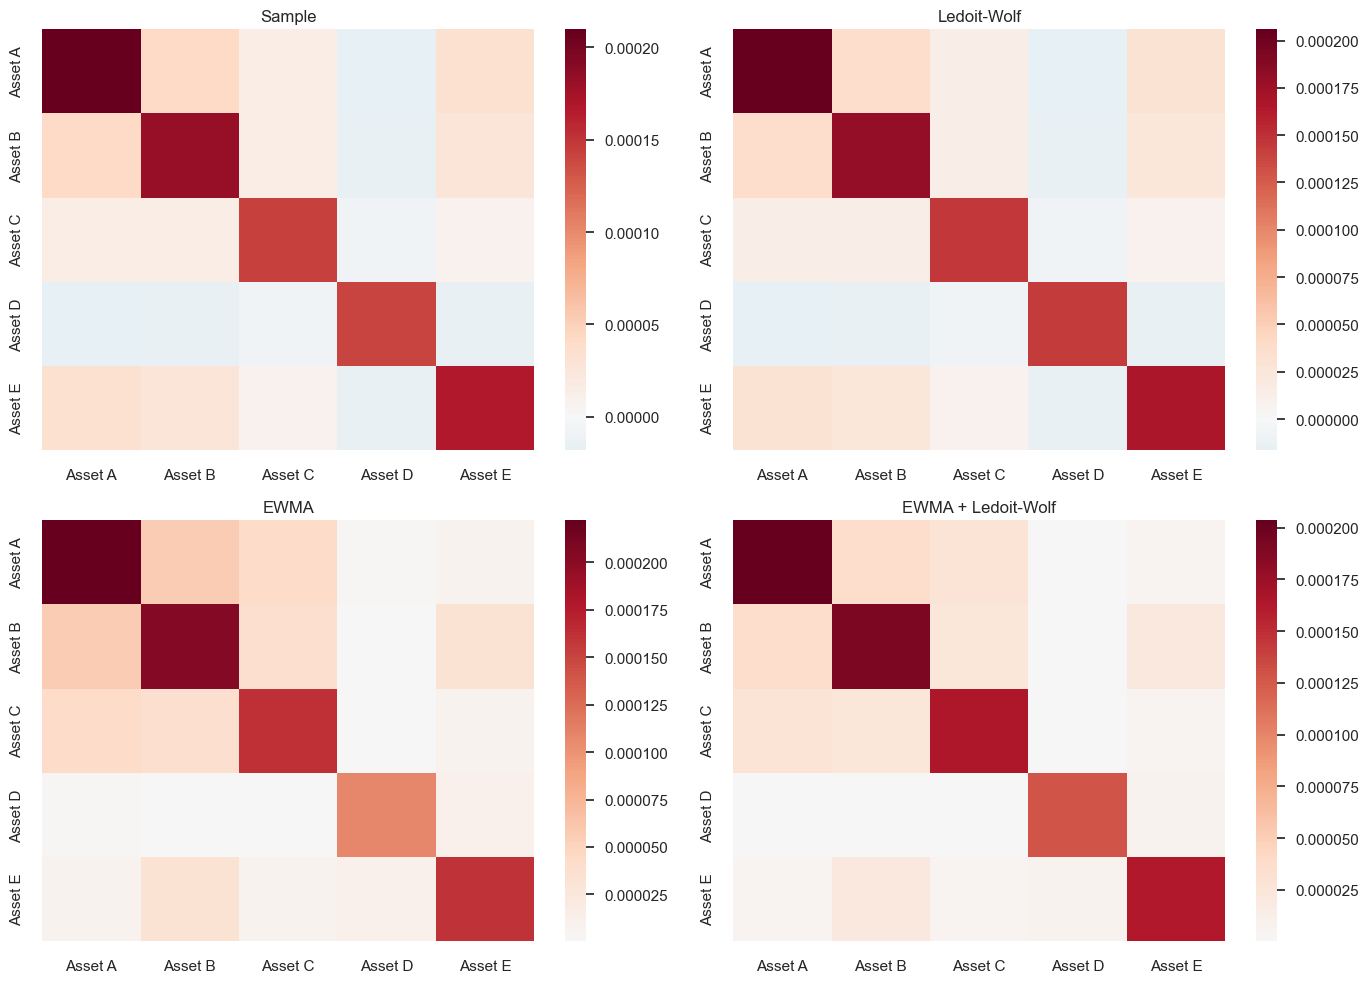

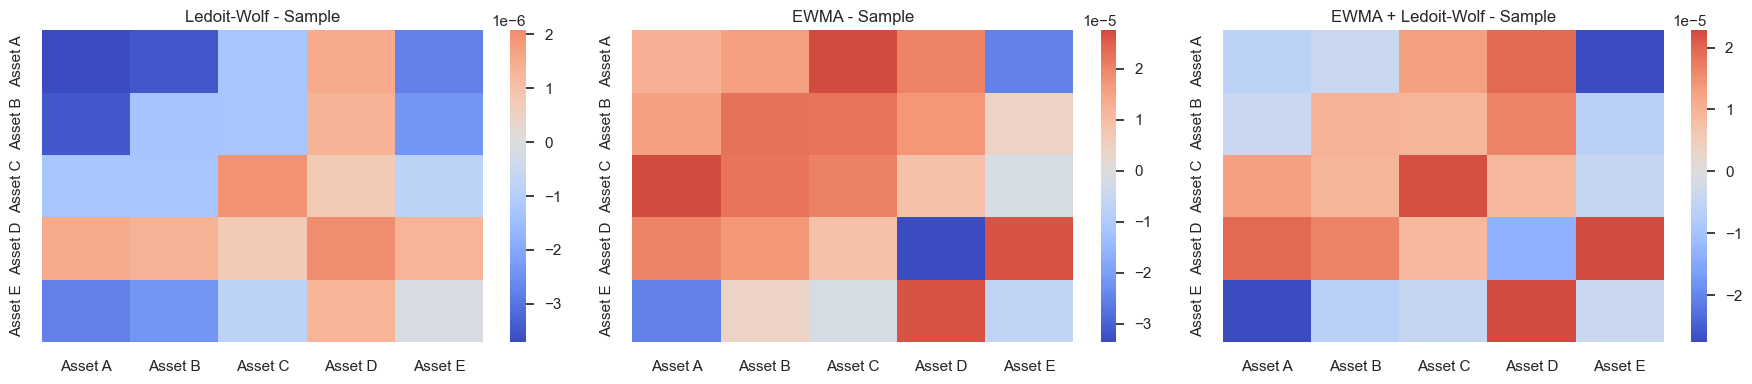

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, covariance_matrix) in zip(axes.flat, covariances.items()):
    sns.heatmap(covariance_matrix, cmap='RdBu_r', center=0.0, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

difference_matrices = {
    'Ledoit-Wolf - Sample': ledoit_cov - sample_cov,
    'EWMA - Sample': ewma_cov - sample_cov,
    'EWMA + Ledoit-Wolf - Sample': ewma_ledoit_cov - sample_cov,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (title, difference_matrix) in zip(axes, difference_matrices.items()):
    sns.heatmap(difference_matrix, cmap='coolwarm', center=0.0, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 7. Eigenvalue Comparison
Eigenvalues summarize the risk spectrum implied by each covariance matrix. Shrinkage typically compresses the most extreme eigenvalues and improves conditioning.

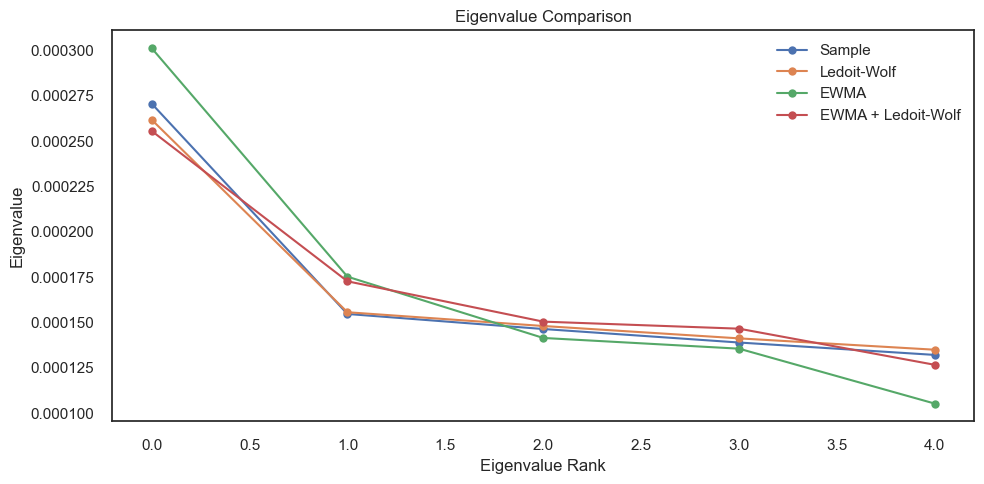

In [6]:
def sorted_eigenvalues(covariance_matrix: pd.DataFrame) -> np.ndarray:
    return np.sort(np.linalg.eigvalsh(covariance_matrix.values))[::-1]


fig, ax = plt.subplots(figsize=(10, 5))
for title, covariance_matrix in covariances.items():
    ax.plot(sorted_eigenvalues(covariance_matrix), marker='o', label=title)
ax.set_title('Eigenvalue Comparison')
ax.set_xlabel('Eigenvalue Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Correlation Structure Comparison
To isolate dependence structure from absolute volatility levels, we convert each covariance matrix to a correlation matrix and compare the resulting heatmaps.

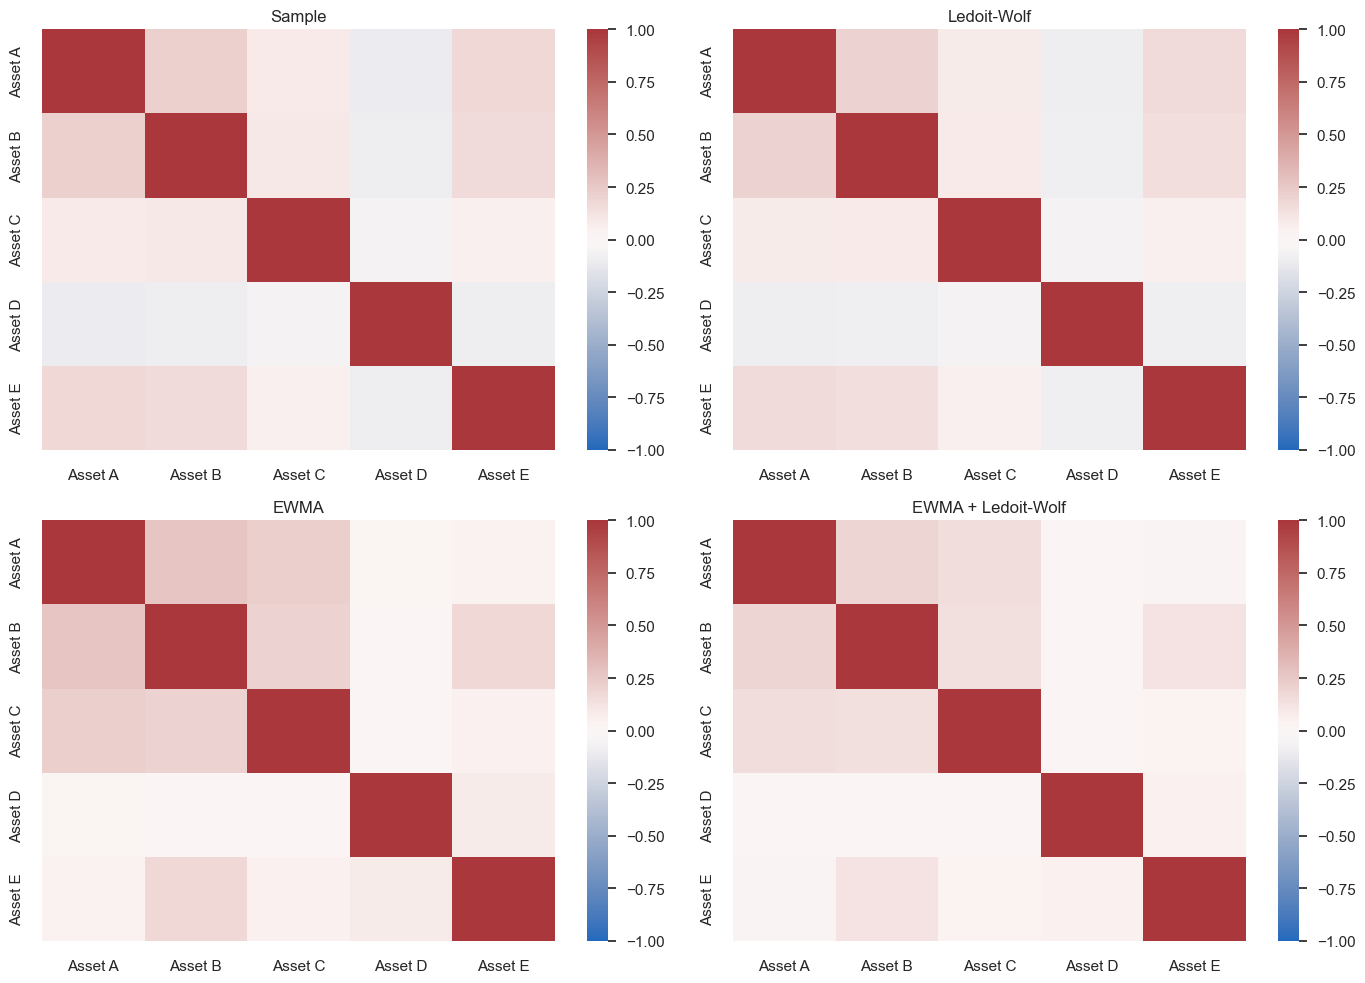

In [7]:
def covariance_to_correlation(covariance_matrix: pd.DataFrame) -> pd.DataFrame:
    std = np.sqrt(np.diag(covariance_matrix.values))
    correlation_values = covariance_matrix.values / np.outer(std, std)
    return pd.DataFrame(
        correlation_values,
        index=covariance_matrix.index,
        columns=covariance_matrix.columns,
    )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, covariance_matrix) in zip(axes.flat, covariances.items()):
    correlation_matrix = covariance_to_correlation(covariance_matrix)
    sns.heatmap(correlation_matrix, cmap='vlag', center=0.0, vmin=-1.0, vmax=1.0, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 9. Covariance Stability Discussion
We summarize the distance from the sample covariance matrix and the average off-diagonal correlation level to support later portfolio construction research.

In [8]:
def average_off_diagonal_correlation(covariance_matrix: pd.DataFrame) -> float:
    correlation_matrix = covariance_to_correlation(covariance_matrix)
    mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    return float(correlation_matrix.where(mask).stack().mean())


stability_summary = pd.DataFrame(
    {
        'frobenius_distance_vs_sample': [
            float(np.linalg.norm((covariance_matrix - sample_cov).values, ord='fro'))
            for covariance_matrix in covariances.values()
        ],
        'average_off_diagonal_correlation': [
            average_off_diagonal_correlation(covariance_matrix)
            for covariance_matrix in covariances.values()
        ],
    },
    index=covariances.keys(),
)
stability_summary


,frobenius_distance_vs_sample,average_off_diagonal_correlation
Sample,0.000000,0.043084
Ledoit-Wolf,0.000010,0.039998
EWMA,0.000098,0.108090
EWMA + Ledoit-Wolf,0.000074,0.073218


### Discussion Notes
- Sample covariance is the baseline but is typically the noisiest estimate.
- Ledoit-Wolf shrinkage regularizes extreme entries and often improves numerical stability.
- EWMA reacts faster to recent co-movement changes because it emphasizes newer observations.
- EWMA plus Ledoit-Wolf is a strong candidate for later rolling portfolio construction because it combines responsiveness with shrinkage control.